In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.environ["OMP_NUM_THREADS"] = "1"
np.random.seed(42)

PROJECT_ROOT_DIR = "."
PROJECT_ID = "customer_segmentation"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", PROJECT_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)


def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Customer Segmentation

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.metrics import silhouette_samples, silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

In [11]:
cust_data = pd.read_csv(
    r"C:\Users\USER\ipnyb files\Machine Learning\Unsupervised learning\datasets\Mall_Customers.csv",
    index_col="CustomerID",
)

In [12]:
cust_data.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40


In [13]:
cust_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    str  
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3), str(1)
memory usage: 7.4 KB


In [14]:
cust_data.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [15]:
cust_data['Gender'] = cust_data['Gender'].map({'Male':0, 'Female':1})

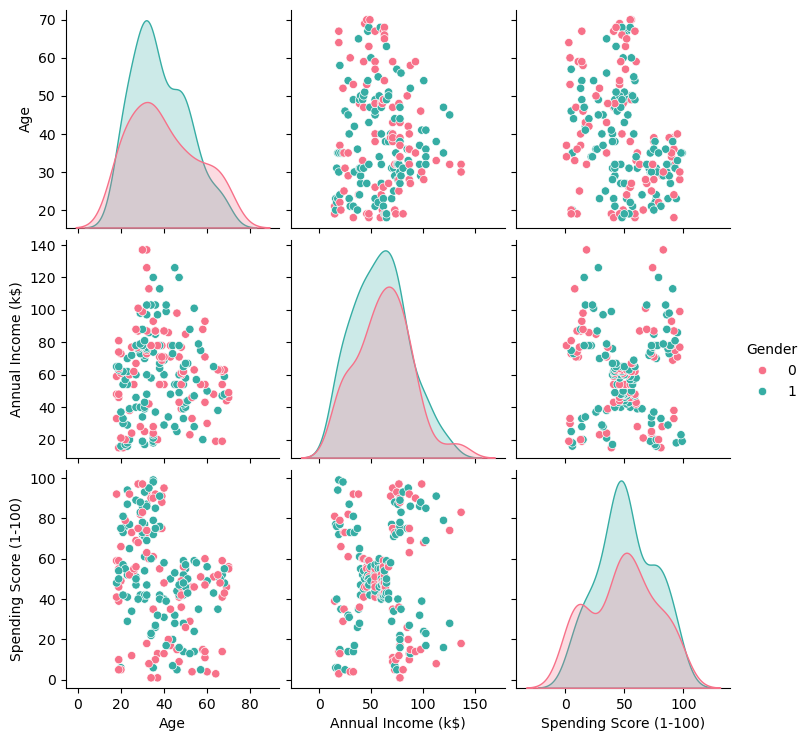

In [16]:
sns.pairplot(
    cust_data,
    vars=["Age", "Annual Income (k$)", "Spending Score (1-100)"],
    hue="Gender",
    palette="husl",
)
plt.show()

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cust_data)

In [ ]:
inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)



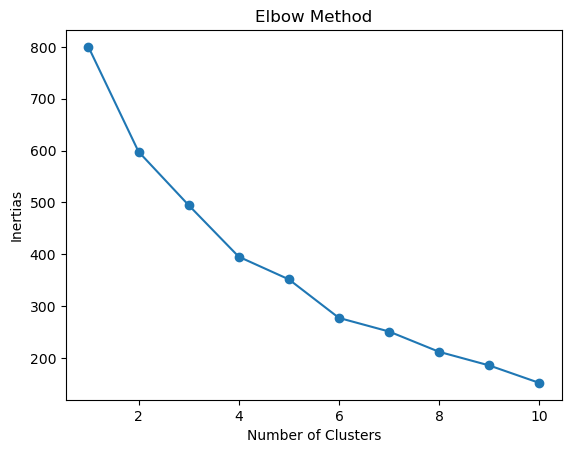

In [20]:
plt.plot(range(1, 11), inertias, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertias")

plt.show()

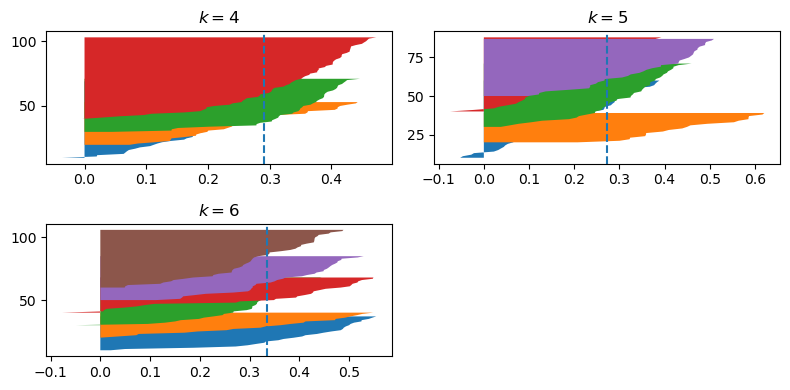

In [26]:
plt.figure(figsize=(8,4))

for k in range(4, 7):
    plt.subplot(2, 2, k - 3)

    labels = KMeans(n_clusters=k, random_state=42).fit_predict(X_scaled)

    avg_score = silhouette_score(X_scaled, labels)
    coeffs = silhouette_samples(X_scaled, labels)

    y_lower = 10

    for i in range(k):
        cluster_sil_coeffs = coeffs[labels==i]
        cluster_sil_coeffs.sort()

        size = cluster_sil_coeffs.shape[0]
        y_upper = y_lower + size

        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil_coeffs)

        y_lower = y_lower + 10

    plt.title(f"$k=${k}")
    plt.axvline(avg_score, linestyle="--")


plt.tight_layout()
plt.show()